# 🏠 Análise e Predição de Preços de Imóveis nos Estados Unidos
## Desafio C3 — Análise de Dados e Machine Learning

**Integrantes:** Renan Fortunato Silveira · Thiago Rosetti Miranda
**Disciplina:** Análise de Dados e Machine Learning · **Instituição:** FAESA Centro Universitário
**Dataset:** *House Prices - Advanced Regression Techniques* (Kaggle) — base de Ames, Iowa

---

### 🎯 Objetivo
Explorar uma base real de venda de imóveis e construir modelos de *machine learning* capazes de:
- **prever o preço de venda** de uma casa (regressão);
- **classificar** o imóvel como de preço **alto ou baixo** (classificação);
- **descobrir padrões** ocultos sem usar o preço (clusterização, redução de dimensionalidade,
  regras de associação e detecção de anomalias).

### 🧪 Metodologia
O projeto segue um fluxo inspirado no **CRISP-DM**, em 7 etapas:

| Etapa | Pergunta que responde |
|---|---|
| 1. Análise Exploratória (EDA) | Como os dados se comportam? |
| 2. Feature Engineering | Como preparar os dados para os modelos? |
| 3. Regressão | Quanto vale a casa? |
| 4. Classificação | A casa é cara ou barata? |
| 5. Clusterização | Que perfis de casas existem? |
| 6. Redução de Dimensionalidade | Como visualizar 200+ variáveis? |
| 7. Associação e Outliers | Que regras e anomalias existem? |

Ao final, comparamos todos os modelos e discutimos **conclusões, limitações e trabalhos futuros**.
Usamos `RANDOM_STATE = 42` em todo o projeto para garantir **reprodutibilidade**.

## 0. Configuração do ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 120)
print("Ambiente configurado ✅")

Ambiente configurado ✅


## 1. Análise Exploratória de Dados (EDA)

> *Antes de modelar, é preciso conhecer os dados.*

In [2]:
df = pd.read_csv("../data/train.csv")
print(f"O dataset possui {df.shape[0]} imóveis e {df.shape[1]} variáveis.")
df.head()

O dataset possui 1460 imóveis e 81 variáveis.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.1 Tipos de variáveis e visão geral
A base mistura variáveis **numéricas** (áreas, anos, contagens) e **categóricas**
(bairro, qualidade, acabamentos). `Id` é apenas um identificador e será descartado.

Numéricas (sem Id/SalePrice): 36
Categóricas               : 43
Valores faltantes (total) : 7,829


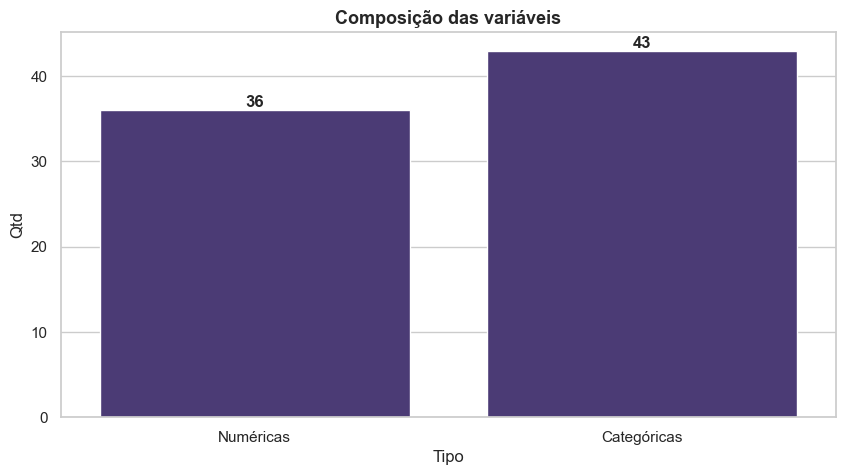

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(["Id", "SalePrice"]).tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numéricas (sem Id/SalePrice): {len(num_cols)}")
print(f"Categóricas               : {len(cat_cols)}")
print(f"Valores faltantes (total) : {df.isnull().sum().sum():,}")

resumo = pd.DataFrame({"Tipo": ["Numéricas", "Categóricas"],
                       "Qtd": [len(num_cols), len(cat_cols)]})
ax = sns.barplot(data=resumo, x="Tipo", y="Qtd")
ax.set_title("Composição das variáveis")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.show()

### 1.2 A variável-alvo `SalePrice`
A distribuição é **assimétrica à direita**. Aplicar `log` aproxima-a de uma Normal —
o que beneficia os modelos lineares e estabiliza a variância.

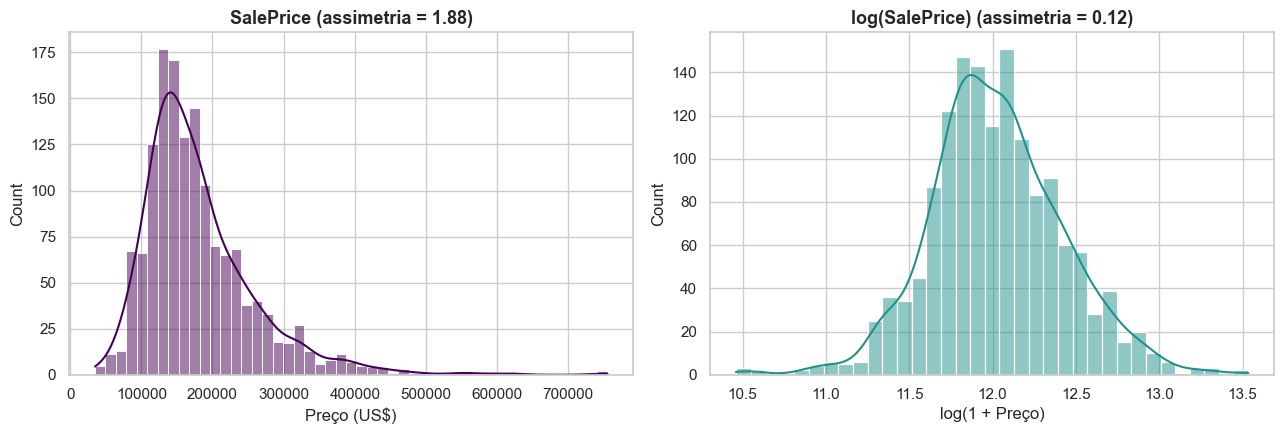

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="#440154")
axes[0].set_title(f"SalePrice (assimetria = {df['SalePrice'].skew():.2f})")
axes[0].set_xlabel("Preço (US$)")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1], color="#21918c")
axes[1].set_title(f"log(SalePrice) (assimetria = {np.log1p(df['SalePrice']).skew():.2f})")
axes[1].set_xlabel("log(1 + Preço)")
plt.tight_layout(); plt.show()
print(df["SalePrice"].describe().round(0))

### 1.3 Valores faltantes
Na maior parte dos casos, `NaN` **não é erro de coleta** e sim *ausência do item*
(ex.: `PoolQC` nulo = casa sem piscina). Trataremos isso na Feature Engineering.

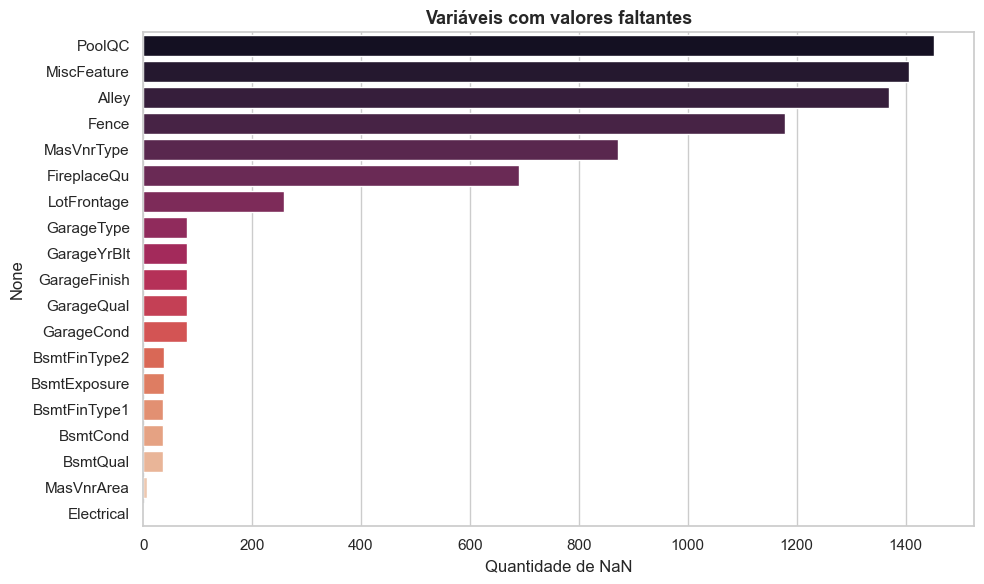

,Faltantes,%
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


In [5]:
falt = df.isnull().sum()
falt = falt[falt > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=falt.values, y=falt.index, palette="rocket")
plt.title("Variáveis com valores faltantes"); plt.xlabel("Quantidade de NaN")
plt.tight_layout(); plt.show()
pd.DataFrame({"Faltantes": falt, "%": (falt/len(df)*100).round(1)})

### 1.4 Correlação com o preço
Qualidade geral (`OverallQual`) e área habitável (`GrLivArea`) lideram a correlação —
casa grande e bem-acabada vale mais.

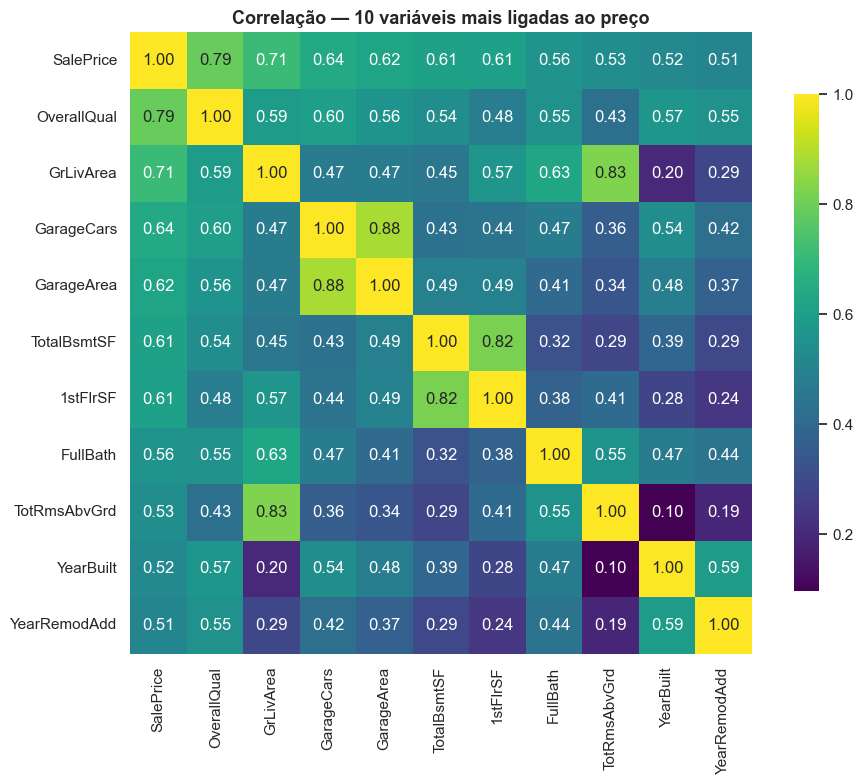

In [6]:
corr = df[num_cols + ["SalePrice"]].corr()
top = corr["SalePrice"].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top].corr(), annot=True, fmt=".2f", cmap="viridis", square=True,
            cbar_kws={"shrink": .8})
plt.title("Correlação — 10 variáveis mais ligadas ao preço")
plt.tight_layout(); plt.show()

### 1.5 Relações visuais e identificação de outliers
Os gráficos confirmam relações positivas fortes. No `GrLivArea × SalePrice` aparecem
**2 imóveis atípicos** (enormes, vendidos muito barato) — serão removidos na próxima etapa.

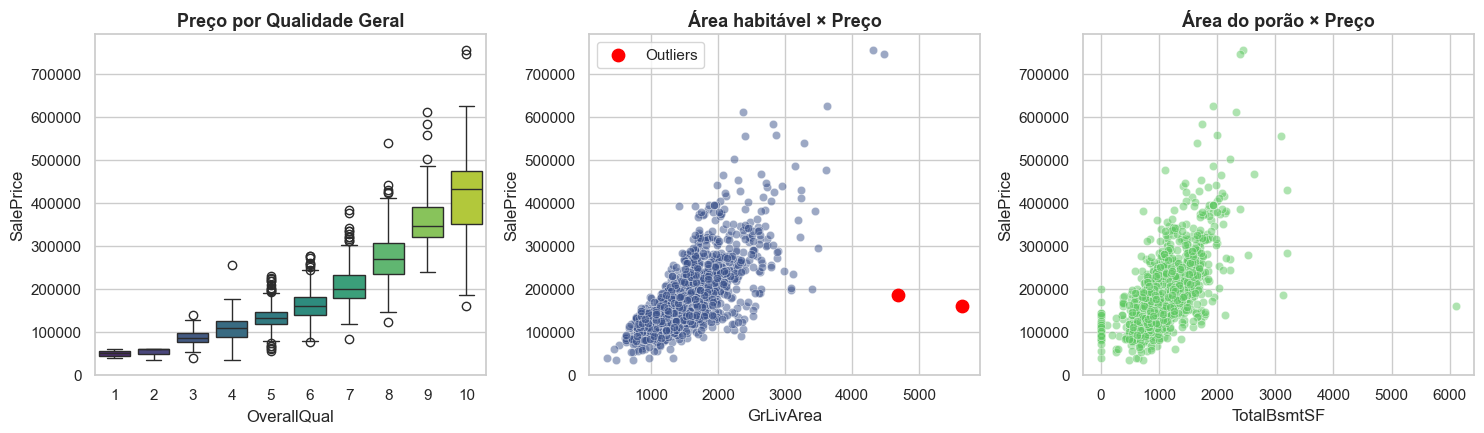

Outliers identificados (serão removidos):


,GrLivArea,SalePrice,OverallQual
523,4676,184750,10
1298,5642,160000,10


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[0], palette="viridis")
axes[0].set_title("Preço por Qualidade Geral")
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", ax=axes[1], alpha=.5, color="#3b528b")
out = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
axes[1].scatter(out["GrLivArea"], out["SalePrice"], color="red", s=80, label="Outliers")
axes[1].legend(); axes[1].set_title("Área habitável × Preço")
sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice", ax=axes[2], alpha=.5, color="#5ec962")
axes[2].set_title("Área do porão × Preço")
plt.tight_layout(); plt.show()
print("Outliers identificados (serão removidos):")
out[["GrLivArea", "SalePrice", "OverallQual"]]

## 2. Feature Engineering

Transformamos os dados brutos em uma matriz pronta para os modelos. Adotamos uma
estratégia de **codificação híbrida**, que é a boa prática para este dataset:

- **Variáveis ordinais** (qualidade, acabamento — têm ordem natural `Ruim < ... < Excelente`)
  → **mapeamento numérico ordinal**, preservando a ordem.
- **Variáveis nominais** (bairro, tipo de telhado — sem ordem) → **one-hot encoding**.

Além disso: removemos outliers, tratamos faltantes, criamos novas *features* e aplicamos
`log` na variável-alvo.

In [8]:
df_fe = df.copy()

# (a) Remover os 2 outliers de GrLivArea identificados na EDA
df_fe = df_fe[~((df_fe["GrLivArea"] > 4000) & (df_fe["SalePrice"] < 300000))].copy()
print(f"Após remoção de outliers: {df_fe.shape[0]} imóveis (antes: {df.shape[0]}).")

# (b) Tratamento de faltantes
none_cols = ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu","GarageType",
             "GarageFinish","GarageQual","GarageCond","BsmtQual","BsmtCond",
             "BsmtExposure","BsmtFinType1","BsmtFinType2","MasVnrType"]
for c in none_cols:
    df_fe[c] = df_fe[c].fillna("None")
for c in ["GarageYrBlt","MasVnrArea"]:
    df_fe[c] = df_fe[c].fillna(0)
df_fe["LotFrontage"] = df_fe.groupby("Neighborhood")["LotFrontage"].transform(
    lambda s: s.fillna(s.median()))
# fallback para colunas restantes
for c in df_fe.columns:
    if df_fe[c].isnull().any():
        if df_fe[c].dtype == "object":
            df_fe[c] = df_fe[c].fillna(df_fe[c].mode()[0])
        else:
            df_fe[c] = df_fe[c].fillna(df_fe[c].median())
print("Faltantes restantes:", int(df_fe.drop(columns=['Id']).isnull().sum().sum()))

Após remoção de outliers: 1458 imóveis (antes: 1460).
Faltantes restantes: 0


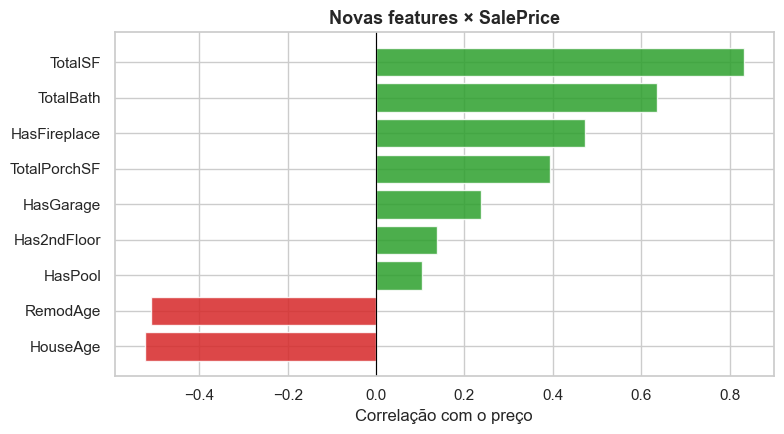

9 novas features criadas.


In [9]:
# (c) Criação de novas features de domínio
df_fe["TotalSF"]       = df_fe["TotalBsmtSF"] + df_fe["1stFlrSF"] + df_fe["2ndFlrSF"]
df_fe["TotalBath"]     = (df_fe["FullBath"] + 0.5*df_fe["HalfBath"]
                          + df_fe["BsmtFullBath"] + 0.5*df_fe["BsmtHalfBath"])
df_fe["TotalPorchSF"]  = (df_fe["OpenPorchSF"] + df_fe["EnclosedPorch"]
                          + df_fe["3SsnPorch"] + df_fe["ScreenPorch"] + df_fe["WoodDeckSF"])
df_fe["HouseAge"]      = df_fe["YrSold"] - df_fe["YearBuilt"]
df_fe["RemodAge"]      = df_fe["YrSold"] - df_fe["YearRemodAdd"]
df_fe["HasGarage"]     = (df_fe["GarageArea"] > 0).astype(int)
df_fe["HasFireplace"]  = (df_fe["Fireplaces"] > 0).astype(int)
df_fe["HasPool"]       = (df_fe["PoolArea"] > 0).astype(int)
df_fe["Has2ndFloor"]   = (df_fe["2ndFlrSF"] > 0).astype(int)

new_feats = ["TotalSF","TotalBath","TotalPorchSF","HouseAge","RemodAge",
             "HasGarage","HasFireplace","HasPool","Has2ndFloor"]
nc = df_fe[new_feats + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values()
plt.figure(figsize=(8, 4.5))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in nc.values]
plt.barh(nc.index, nc.values, color=colors, alpha=.85)
plt.axvline(0, color="black", lw=.8); plt.title("Novas features × SalePrice")
plt.xlabel("Correlação com o preço"); plt.tight_layout(); plt.show()
print(f"{len(new_feats)} novas features criadas.")

In [10]:
# (d) CODIFICAÇÃO HÍBRIDA -----------------------------------------------------
quality_map  = {"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
finish_map   = {"None":0,"Unf":1,"RFn":2,"Fin":3}
exposure_map = {"None":0,"No":1,"Mn":2,"Av":3,"Gd":4}
bsmtfin_map  = {"None":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}

ordinal_map = {
    "ExterQual":quality_map, "ExterCond":quality_map, "BsmtQual":quality_map,
    "BsmtCond":quality_map, "HeatingQC":quality_map, "KitchenQual":quality_map,
    "FireplaceQu":quality_map, "GarageQual":quality_map, "GarageCond":quality_map,
    "PoolQC":quality_map, "BsmtExposure":exposure_map, "GarageFinish":finish_map,
    "BsmtFinType1":bsmtfin_map, "BsmtFinType2":bsmtfin_map,
    "Functional":{"Sal":0,"Sev":1,"Maj2":2,"Maj1":3,"Mod":4,"Min2":5,"Min1":6,"Typ":7},
    "LandSlope":{"Sev":0,"Mod":1,"Gtl":2}, "LotShape":{"IR3":0,"IR2":1,"IR1":2,"Reg":3},
    "PavedDrive":{"N":0,"P":1,"Y":2}, "Street":{"Grvl":0,"Pave":1},
    "CentralAir":{"N":0,"Y":1}, "Fence":{"None":0,"MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4},
    "Alley":{"None":0,"Grvl":1,"Pave":2},
}
for col, mp in ordinal_map.items():
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].map(mp).fillna(0).astype(int)

# nominais restantes -> one-hot
nominais = df_fe.select_dtypes(include="object").columns.tolist()
df_fe = pd.get_dummies(df_fe, columns=nominais, drop_first=True)
df_fe = df_fe.drop(columns=["Id"])

# (e) target em log + alvos
y       = df_fe["SalePrice"]
y_log   = np.log1p(y)
preco_mediano = y.median()
y_bin   = (y > preco_mediano).astype(int)
X       = df_fe.drop(columns=["SalePrice"])

print(f"Matriz final: {X.shape[0]} imóveis × {X.shape[1]} features")
print(f"  • {len(ordinal_map)} variáveis ordinais → encoding numérico")
print(f"  • {len(nominais)} variáveis nominais → one-hot")
print(f"  • Limiar (mediana) p/ classificação: US$ {preco_mediano:,.0f}")

Matriz final: 1458 imóveis × 209 features
  • 22 variáveis ordinais → encoding numérico
  • 21 variáveis nominais → one-hot
  • Limiar (mediana) p/ classificação: US$ 163,000


## 3. Aprendizagem Supervisionada — Regressão

Objetivo: prever `log(SalePrice)`. Comparamos 4 modelos, do mais simples ao mais sofisticado:

| Modelo | Ideia |
|---|---|
| Linear **Simples** | usa só `TotalSF` (baseline didático) |
| Linear **Múltipla** | usa todas as features |
| **Random Forest** | floresta de árvores |
| **Gradient Boosting** | árvores sequenciais que corrigem erros |

**Métricas:** RMSE, MAE (em escala log) e **R²** (variância explicada).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Treino: 1166 | Teste: 292


### 3.1 Regressão Linear Simples (baseline)
Uma única variável — a área total — para ilustrar o conceito. A reta vermelha é o modelo.

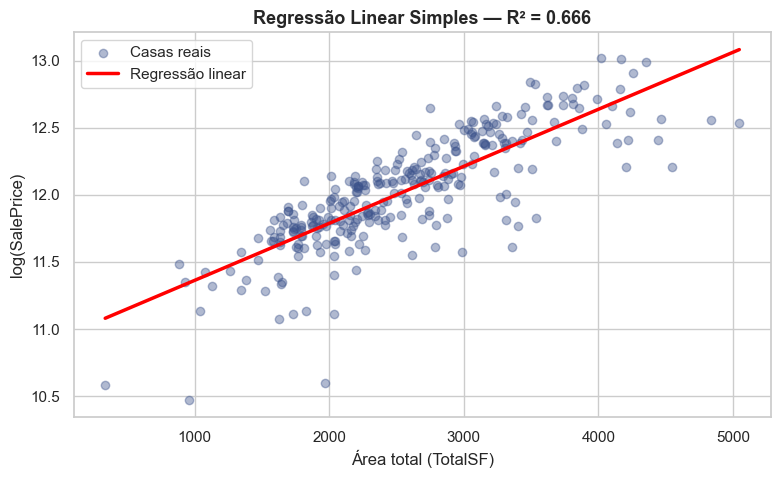

In [12]:
lin_s = LinearRegression().fit(X_train[["TotalSF"]], y_train)
r2_s = r2_score(y_test, lin_s.predict(X_test[["TotalSF"]]))
plt.figure(figsize=(9, 5))
plt.scatter(X_test["TotalSF"], y_test, alpha=.4, color="#3b528b", label="Casas reais")
ordem = X_test["TotalSF"].sort_values().index
plt.plot(X_test.loc[ordem, "TotalSF"], lin_s.predict(X_test.loc[ordem, ["TotalSF"]]),
         color="red", lw=2.5, label="Regressão linear")
plt.xlabel("Área total (TotalSF)"); plt.ylabel("log(SalePrice)")
plt.title(f"Regressão Linear Simples — R² = {r2_s:.3f}"); plt.legend(); plt.show()

### 3.2 Regressão Múltipla e modelos de *ensemble*

In [13]:
modelos_reg = {
    "Linear Múltipla":   (LinearRegression(), True),
    "Random Forest":     (RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE), False),
}
res_reg, preds = [], {}
for nome, (modelo, usa_escala) in modelos_reg.items():
    Xtr, Xte = (X_train_sc, X_test_sc) if usa_escala else (X_train, X_test)
    modelo.fit(Xtr, y_train)
    p = modelo.predict(Xte); preds[nome] = p
    res_reg.append({"Modelo": nome,
                    "RMSE (log)": np.sqrt(mean_squared_error(y_test, p)),
                    "MAE (log)":  mean_absolute_error(y_test, p),
                    "R²":         r2_score(y_test, p)})
tab_reg = pd.DataFrame(res_reg).sort_values("R²", ascending=False).reset_index(drop=True)
tab_reg.round(4)

,Modelo,RMSE (log),MAE (log),R²
0,Gradient Boosting,0.1217,0.0824,0.9122
1,Linear Múltipla,0.1302,0.0907,0.8995
2,Random Forest,0.1446,0.0958,0.8759


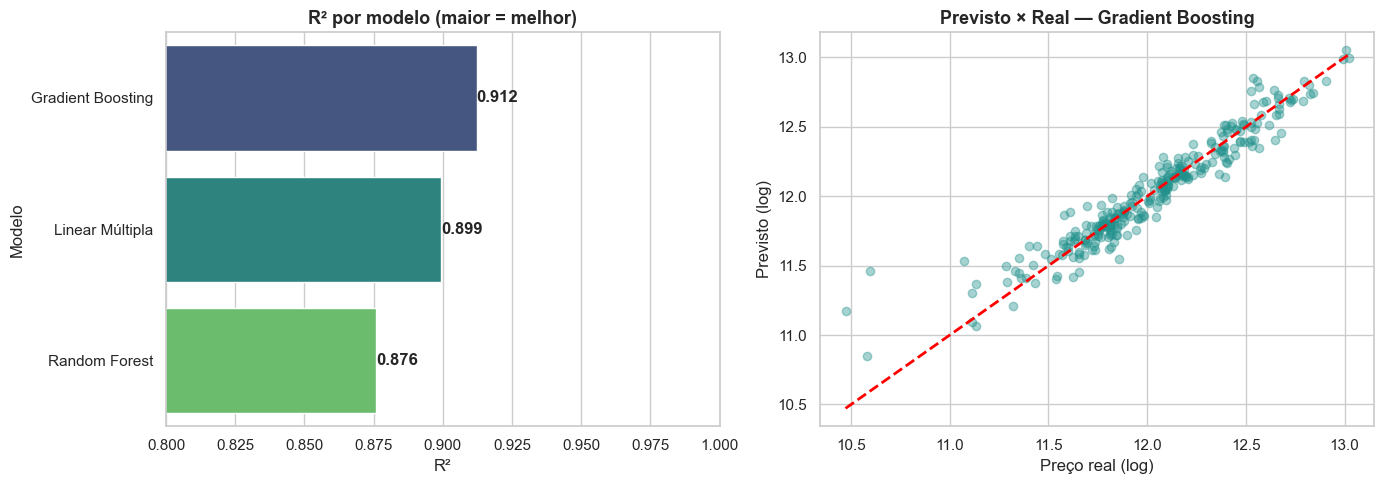

🏆 Melhor modelo de regressão: Gradient Boosting


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=tab_reg, x="R²", y="Modelo", ax=axes[0], palette="viridis")
axes[0].set_xlim(0.8, 1.0); axes[0].set_title("R² por modelo (maior = melhor)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y()+p.get_height()/2),
                     ha="left", va="center", fontweight="bold")
melhor_reg = tab_reg.iloc[0]["Modelo"]
axes[1].scatter(y_test, preds[melhor_reg], alpha=.4, color="#21918c")
lims = [y_test.min(), y_test.max()]; axes[1].plot(lims, lims, "r--", lw=2)
axes[1].set_xlabel("Preço real (log)"); axes[1].set_ylabel("Previsto (log)")
axes[1].set_title(f"Previsto × Real — {melhor_reg}")
plt.tight_layout(); plt.show()
print(f"🏆 Melhor modelo de regressão: {melhor_reg}")

### 3.3 Variáveis mais importantes

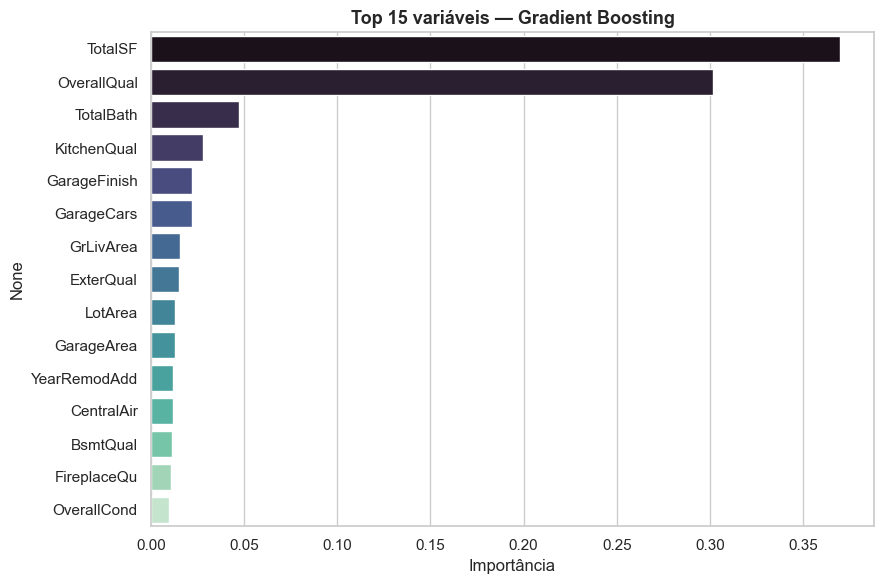

In [15]:
modelo_imp = modelos_reg["Gradient Boosting"][0]
imp = pd.Series(modelo_imp.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, palette="mako")
plt.title("Top 15 variáveis — Gradient Boosting"); plt.xlabel("Importância")
plt.tight_layout(); plt.show()

## 4. Aprendizagem Supervisionada — Classificação

Trocamos a pergunta: em vez de *quanto vale*, perguntamos **se a casa é cara ou barata**
(`1` = acima da mediana). Comparamos **Regressão Logística** e **Random Forest** com
*accuracy, precision, recall, F1* e **AUC-ROC**.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X, y_bin, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin)
sc_clf = StandardScaler()
Xc_tr_sc = sc_clf.fit_transform(Xc_tr)
Xc_te_sc = sc_clf.transform(Xc_te)
print(f"Classes — barata(0): {(y_bin==0).sum()} | cara(1): {(y_bin==1).sum()}")

clf_log = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xc_tr_sc, yc_tr)
clf_rf  = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_tr, yc_tr)
modelos_clf = {"Regressão Logística": (clf_log, Xc_te_sc), "Random Forest": (clf_rf, Xc_te)}

res_clf = []
for nome, (m, Xt) in modelos_clf.items():
    pred, proba = m.predict(Xt), m.predict_proba(Xt)[:, 1]
    res_clf.append({"Modelo": nome, "Acurácia": accuracy_score(yc_te, pred),
                    "Precisão": precision_score(yc_te, pred), "Recall": recall_score(yc_te, pred),
                    "F1": f1_score(yc_te, pred), "AUC-ROC": roc_auc_score(yc_te, proba)})
tab_clf = pd.DataFrame(res_clf).sort_values("F1", ascending=False).reset_index(drop=True)
tab_clf.round(4)

Classes — barata(0): 731 | cara(1): 727


,Modelo,Acurácia,Precisão,Recall,F1,AUC-ROC
0,Regressão Logística,0.9075,0.8889,0.9315,0.9097,0.9697
1,Random Forest,0.9110,0.9412,0.8767,0.9078,0.9827


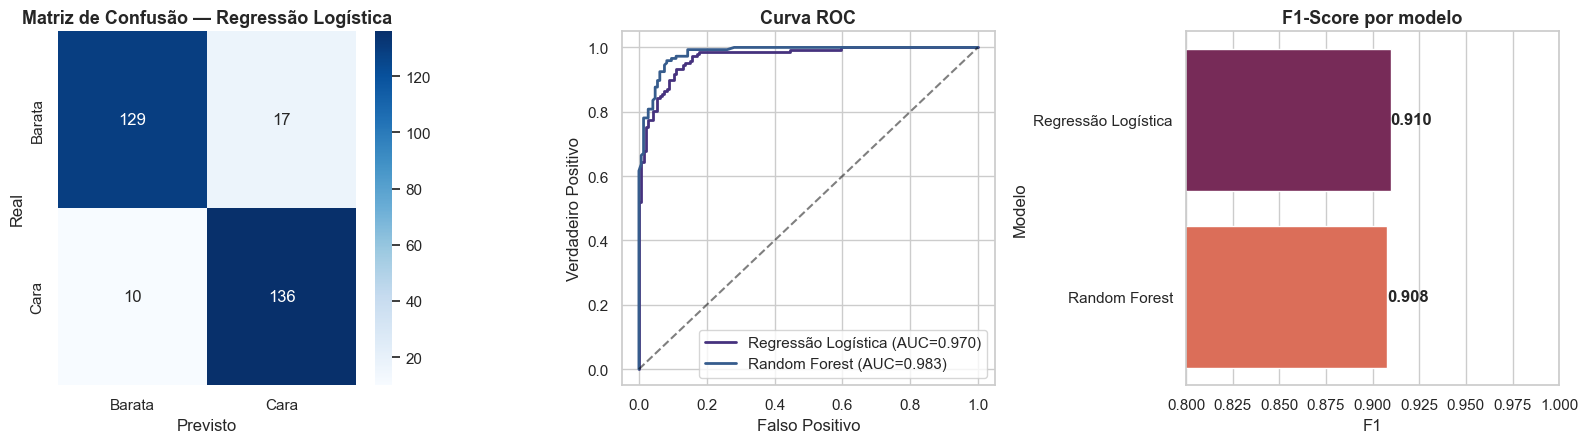

🏆 Melhor classificador: Regressão Logística


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
melhor_clf = tab_clf.iloc[0]["Modelo"]
m_b, Xt_b = modelos_clf[melhor_clf]
cm = confusion_matrix(yc_te, m_b.predict(Xt_b))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Barata","Cara"], yticklabels=["Barata","Cara"])
axes[0].set_title(f"Matriz de Confusão — {melhor_clf}")
axes[0].set_xlabel("Previsto"); axes[0].set_ylabel("Real")
for nome, (m, Xt) in modelos_clf.items():
    proba = m.predict_proba(Xt)[:, 1]; fpr, tpr, _ = roc_curve(yc_te, proba)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nome} (AUC={roc_auc_score(yc_te, proba):.3f})")
axes[1].plot([0,1],[0,1],"k--", alpha=.5); axes[1].legend()
axes[1].set_xlabel("Falso Positivo"); axes[1].set_ylabel("Verdadeiro Positivo"); axes[1].set_title("Curva ROC")
sns.barplot(data=tab_clf, x="F1", y="Modelo", ax=axes[2], palette="rocket")
axes[2].set_xlim(0.8, 1.0); axes[2].set_title("F1-Score por modelo")
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y()+p.get_height()/2),
                     ha="left", va="center", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"🏆 Melhor classificador: {melhor_clf}")

> ⏳ *As etapas de aprendizagem não supervisionada (clusterização, redução de dimensionalidade, associação e outliers) e as conclusões finais são desenvolvidas na sequência do projeto.*